In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
import seaborn as sns

import os
import json
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import binomtest

In [14]:
#X - features

data_path = "C:\\Users\\Viktorija\\Desktop\\VR\\RV1\\git\\FitnessExperimentServer\\FitnessExperimentServer\\data"
frequency = 104

files = []

for i in os.listdir(data_path):
    with open((data_path + "\\" + i), "r") as json_file:
        files.append(json.load(json_file))

i = 0

while (i < len(files)):
    if (files[i]["frequency"] != frequency):
        del files[i]
        i -= 1
    i += 1

#files contains all files with frequency 26
features = []
labels = []

for f in files:

    x_coords_acc = []
    y_coords_acc = []
    z_coords_acc = []
    x_coords_gyr = []
    y_coords_gyr = []
    z_coords_gyr = []

    for acc_measurement in f["accMeasurements"]:
        x_coords_acc.append(acc_measurement["x"])
        y_coords_acc.append(acc_measurement["y"])
        z_coords_acc.append(acc_measurement["z"])

    for gyr_measurement in f["gyrMeasurements"]:
        x_coords_gyr.append(gyr_measurement["x"])
        y_coords_gyr.append(gyr_measurement["y"])
        z_coords_gyr.append(gyr_measurement["z"])

    x_coords_acc = np.array(x_coords_acc)
    y_coords_acc = np.array(y_coords_acc)
    z_coords_acc = np.array(z_coords_acc)
    x_coords_gyr = np.array(x_coords_gyr)
    y_coords_gyr = np.array(y_coords_gyr)
    z_coords_gyr = np.array(z_coords_gyr)
    
    experiment = []

    # accelerometer x-axis features
    experiment.append(x_coords_acc.min())
    experiment.append(x_coords_acc.max())
    experiment.append(np.mean(x_coords_acc))
    experiment.append(np.std(x_coords_acc))

    # accelerometer y-axis features
    experiment.append(y_coords_acc.min())
    experiment.append(y_coords_acc.max())
    experiment.append(np.mean(y_coords_acc))
    experiment.append(np.std(y_coords_acc))

    # accelerometer z-axis features
    experiment.append(z_coords_acc.min())
    experiment.append(z_coords_acc.max())
    experiment.append(np.mean(z_coords_acc))
    experiment.append(np.std(z_coords_acc))

    # gyroscope x-axis features
    experiment.append(x_coords_gyr.min())
    experiment.append(x_coords_gyr.max())
    experiment.append(np.mean(x_coords_gyr))
    experiment.append(np.std(x_coords_gyr))

    # gyroscope y-axis features
    experiment.append(y_coords_gyr.min())
    experiment.append(y_coords_gyr.max())
    experiment.append(np.mean(y_coords_gyr))
    experiment.append(np.std(y_coords_gyr))

    # gyroscope z-axis features
    experiment.append(z_coords_gyr.min())
    experiment.append(z_coords_gyr.max())
    experiment.append(np.mean(z_coords_gyr))
    experiment.append(np.std(z_coords_gyr))

    features.append(experiment)

    # if f["experimentType"] == "Overhead triceps extension":
    #     labels.append(1)
    # elif f["experimentType"] == "Bicep curl":
    #     labels.append(2)
    # elif f["experimentType"] == "Tricep dumbbell kickback":
    #     labels.append(3)

    labels.append(f["user"])

print(labels)
print(features)

['OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'OC', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS', 'VS']
[[-0.6584054827690125, 10.632649421691895, 6.268251413911677, 2.631580830102131, -11.504138946533203, 0.9672574996948242, -4.96827968981711, 3.2081543764521783, -7.1921820640563965, 4.388571739196777, -3.5516716063864386, 2.3574222375936293, -125.54499816894531, 115.29000091552734, 0.3588093425146935, 52.59485648007913, -89.10124969482422, 79.28375244140625, 1.0203731116890142, 24.21764875329526, -180.52125549316406, 133.6737518310547, -0.2419308875791101, 80.25746084131698], [0.42616790533065796, 10.395624160766602, 6.524492765495029, 2.5452387644912116, -11.601104736328125, 2.05781626701355, -4.846354208905503, 3.29793833599126, 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.4, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Accuracy: 1.0
Precision: 1.00
['OC', 'OC', 'VS', 'VS', 'OC', 'VS', 'VS', 'VS', 'OC', 'VS', 'VS', 'VS', 'VS', 'OC', 'VS', 'OC', 'OC', 'OC', 'VS', 'OC', 'VS', 'OC', 'VS', 'VS']
['OC' 'OC' 'VS' 'VS' 'OC' 'VS' 'VS' 'VS' 'OC' 'VS' 'VS' 'VS' 'VS' 'OC'
 'VS' 'OC' 'OC' 'OC' 'VS' 'OC' 'VS' 'OC' 'VS' 'VS']


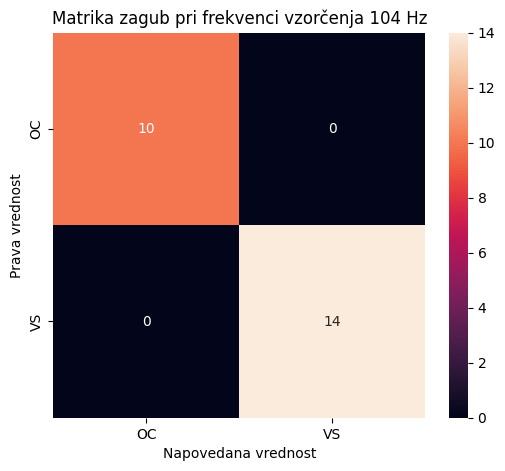

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

precision = precision_score(y_test, y_pred, average='macro')
print(f"Precision: {precision:.2f}")

print(y_test)
print(y_pred)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
ax = sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Napovedana vrednost')
ax.xaxis.set_ticklabels(['OC', 'VS'])
plt.ylabel('Prava vrednost')
ax.yaxis.set_ticklabels(['OC', 'VS'])
plt.title('Matrika zamenjav pri frekvenci vzorčenja 104 Hz')
plt.show()

In [17]:
total_predictions = len(y_test)
correct_predictions = 0

for i in range(len(y_pred)):
    if y_pred[i] == y_test[i]:
        correct_predictions += 1

print("Total predictions: ", total_predictions)
print("Correct predictions: ", correct_predictions)

expected_accuracy = 0.9
alpha = 0.1

test_result = binomtest(correct_predictions, total_predictions, expected_accuracy, alternative='greater')

print("p_value: ", test_result.pvalue)

if (test_result.pvalue < alpha):
    print("Hipoteza potrjena!")
else:
    print("Hipoteza zavrnjena!")

Total predictions:  24
Correct predictions:  24
p_value:  0.07976644307687251
Hipoteza potrjena!
